In [15]:
from google.colab import drive
drive.mount("/content/drive")

!pip install -q transformers accelerate sentencepiece scipy

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
from pathlib import Path
import random
import copy
import time
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from sklearn.metrics import (
    cohen_kappa_score,
    mean_absolute_error,
    mean_squared_error,
)

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings("ignore")

In [17]:
# ============================================================
# Experiment 4: DeBERTa-v3-large Regression
# A100 stable config
# ============================================================

PROJECT_NAME = "IELTS-Writing-Evals"

TEXT_COL = "essay"
SET_COL = "essay_set"
SCORE_COL = "domain1_score"

METHOD_NAME = "DeBERTa-v3-large Regression"
MODEL_NAME = "microsoft/deberta-v3-large"

SEED = 42

# DeBERTa-v3-large dùng max length 512.
MAX_LENGTH = 512

# A100 stable config
BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 2
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS

# Training config
EPOCHS = 15
PATIENCE = 3

LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
MAX_GRAD_NORM = 0.5

# Tắt AMP để tránh NaN
# A100 chạy FP32/TF32 vẫn ổn, chỉ chậm hơn BF16 một chút nhưng ổn định hơn.
USE_AMP = False
AMP_DTYPE = torch.float32
USE_GRAD_SCALER = False

# Với A100, tắt gradient checkpointing để train nhanh hơn.
# Nếu bị OOM thì đổi thành True.
USE_GRADIENT_CHECKPOINTING = False

# Output files
RESULT_FILENAME = "experiment4_deberta_v3_large_results.csv"
PREDICTION_FILENAME = "experiment4_deberta_v3_large_predictions.csv"


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cho phép TF32 trên A100 để FP32 nhanh hơn
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Effective batch size:", EFFECTIVE_BATCH_SIZE)

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Effective batch size: 16


In [18]:
# ============================================================
# Find project root in Google Drive
# ============================================================

def find_project_root(project_name=PROJECT_NAME):
    search_roots = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/MyDrive/Colab Notebooks"),
        Path("/content"),
    ]

    for root in search_roots:
        if not root.exists():
            continue

        direct_candidate = root / project_name
        if direct_candidate.exists() and direct_candidate.is_dir():
            return direct_candidate

        matches = list(root.rglob(project_name))
        matches = [p for p in matches if p.is_dir() and p.name == project_name]

        if matches:
            return matches[0]

    raise FileNotFoundError(
        f"Cannot find project folder '{project_name}' in Google Drive. "
        "Please make sure the folder exists in MyDrive."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "dataset" / "asap"
RESULT_DIR = PROJECT_ROOT / "benchmark_results" / "ASAP"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

train_path = DATA_DIR / "asap_train.csv"
val_path = DATA_DIR / "asap_val.csv"
test_path = DATA_DIR / "asap_test.csv"

result_path = RESULT_DIR / RESULT_FILENAME
prediction_path = RESULT_DIR / PREDICTION_FILENAME

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Result dir:", RESULT_DIR)

print("\nTrain path:", train_path)
print("Val path:  ", val_path)
print("Test path: ", test_path)

print("\nResult path:", result_path)
print("Prediction path:", prediction_path)

for path in [train_path, val_path, test_path]:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

Project root: /content/drive/MyDrive/ielts/IELTS-Writing-Evals
Data dir: /content/drive/MyDrive/ielts/IELTS-Writing-Evals/dataset/asap
Result dir: /content/drive/MyDrive/ielts/IELTS-Writing-Evals/benchmark_results/ASAP

Train path: /content/drive/MyDrive/ielts/IELTS-Writing-Evals/dataset/asap/asap_train.csv
Val path:   /content/drive/MyDrive/ielts/IELTS-Writing-Evals/dataset/asap/asap_val.csv
Test path:  /content/drive/MyDrive/ielts/IELTS-Writing-Evals/dataset/asap/asap_test.csv

Result path: /content/drive/MyDrive/ielts/IELTS-Writing-Evals/benchmark_results/ASAP/experiment4_deberta_v3_large_results.csv
Prediction path: /content/drive/MyDrive/ielts/IELTS-Writing-Evals/benchmark_results/ASAP/experiment4_deberta_v3_large_predictions.csv


In [19]:
# ============================================================
# Load data
# ============================================================

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

required_cols = {TEXT_COL, SET_COL, SCORE_COL}

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"{name}.csv missing columns: {missing_cols}")

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

print("\nEssay sets:")
print("Train:", sorted(train_df[SET_COL].unique()))
print("Val:  ", sorted(val_df[SET_COL].unique()))
print("Test: ", sorted(test_df[SET_COL].unique()))

# ============================================================
# Hard leakage check
# ============================================================

if "essay_id" in train_df.columns:
    train_ids = set(train_df["essay_id"])
    val_ids = set(val_df["essay_id"])
    test_ids = set(test_df["essay_id"])

    print("\nID overlap check:")
    print("Train-Val overlap: ", len(train_ids & val_ids))
    print("Train-Test overlap:", len(train_ids & test_ids))
    print("Val-Test overlap:  ", len(val_ids & test_ids))

    print("\nDuplicate check:")
    print("Train duplicated:", train_df["essay_id"].duplicated().sum())
    print("Val duplicated:  ", val_df["essay_id"].duplicated().sum())
    print("Test duplicated: ", test_df["essay_id"].duplicated().sum())

    assert len(train_ids & val_ids) == 0, "Leakage: train and val overlap."
    assert len(train_ids & test_ids) == 0, "Leakage: train and test overlap."
    assert len(val_ids & test_ids) == 0, "Leakage: val and test overlap."

summary = pd.DataFrame({
    "train": train_df[SET_COL].value_counts().sort_index(),
    "val": val_df[SET_COL].value_counts().sort_index(),
    "test": test_df[SET_COL].value_counts().sort_index(),
})

summary["total"] = summary["train"] + summary["val"] + summary["test"]

display(summary)

Train: (9084, 5)
Val:   (1296, 5)
Test:  (2596, 5)

Essay sets:
Train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Val:   [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Test:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

ID overlap check:
Train-Val overlap:  0
Train-Test overlap: 0
Val-Test overlap:   0

Duplicate check:
Train duplicated: 0
Val duplicated:   0
Test duplicated:  0


,train,val,test,total
essay_set,,,,
1,1248,180,355,1783
2,1260,180,360,1800
3,1208,173,345,1726
4,1239,177,354,1770
5,1263,180,362,1805
6,1261,180,359,1800
7,1098,157,314,1569
8,507,69,147,723


In [20]:
# ============================================================
# Tokenizer
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", MODEL_NAME)
print("Tokenizer model max length:", tokenizer.model_max_length)

Tokenizer: microsoft/deberta-v3-large
Tokenizer model max length: 1000000000000000019884624838656


In [21]:
# ============================================================
# Dataset
# ============================================================

class EssayRegressionDataset(Dataset):
    def __init__(
        self,
        df,
        tokenizer,
        min_score,
        max_score,
        max_length=MAX_LENGTH,
    ):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.min_score = float(min_score)
        self.max_score = float(max_score)
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text = str(row[TEXT_COL])
        score = float(row[SCORE_COL])

        # Normalize label về [0, 1] để regression ổn định hơn
        if self.max_score > self.min_score:
            score_norm = (score - self.min_score) / (self.max_score - self.min_score)
        else:
            score_norm = 0.0

        encoded = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors=None,
        )

        return {
            "input_ids": torch.tensor(encoded["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(encoded["attention_mask"], dtype=torch.long),
            "score": torch.tensor(score, dtype=torch.float),
            "score_norm": torch.tensor(score_norm, dtype=torch.float),
        }


def create_dataloader(
    df,
    tokenizer,
    min_score,
    max_score,
    batch_size=BATCH_SIZE,
    shuffle=False,
):
    dataset = EssayRegressionDataset(
        df=df,
        tokenizer=tokenizer,
        min_score=min_score,
        max_score=max_score,
        max_length=MAX_LENGTH,
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False,
    )

In [22]:
# ============================================================
# Metrics
# ============================================================

def denormalize_predictions(pred_norm, min_score, max_score):
    pred_norm = np.asarray(pred_norm, dtype=float)
    pred_score = pred_norm * (max_score - min_score) + min_score
    return pred_score


def clip_and_round_predictions(y_pred, min_score, max_score):
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, min_score, max_score)
    y_pred = np.rint(y_pred).astype(int)
    return y_pred


def compute_metrics(y_true, y_pred_int):
    y_true = np.asarray(y_true).astype(int)
    y_pred_int = np.asarray(y_pred_int).astype(int)

    qwk = cohen_kappa_score(y_true, y_pred_int, weights="quadratic")
    mae = mean_absolute_error(y_true, y_pred_int)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_int))

    return {
        "qwk": qwk,
        "mae": mae,
        "rmse": rmse,
    }


# ============================================================
# QWK threshold optimization on validation set only
# ============================================================

def apply_thresholds(y_pred_raw, thresholds, score_values):
    """
    Convert raw continuous predictions to discrete scores.

    Example:
    score_values = [2, 3, 4, 5]
    thresholds = [2.7, 3.4, 4.6]
    """
    y_pred_raw = np.asarray(y_pred_raw, dtype=float)
    thresholds = np.asarray(thresholds, dtype=float)
    score_values = np.asarray(score_values, dtype=int)

    idx = np.digitize(y_pred_raw, thresholds)
    idx = np.clip(idx, 0, len(score_values) - 1)

    return score_values[idx]


def optimize_qwk_thresholds(y_true, y_pred_raw, min_score, max_score):
    """
    Optimize thresholds using validation set only.
    Test set is never used here.
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred_raw = np.asarray(y_pred_raw, dtype=float)

    score_values = np.arange(int(min_score), int(max_score) + 1)

    if len(score_values) <= 1:
        return np.array([]), score_values

    # Round mặc định tương đương threshold ở midpoint
    initial_thresholds = (score_values[:-1] + score_values[1:]) / 2.0

    def objective(thresholds):
        thresholds = np.sort(thresholds)
        y_pred_int = apply_thresholds(y_pred_raw, thresholds, score_values)
        qwk = cohen_kappa_score(y_true, y_pred_int, weights="quadratic")

        if np.isnan(qwk):
            return 1.0

        return -qwk

    result = minimize(
        objective,
        initial_thresholds,
        method="Nelder-Mead",
        options={
            "maxiter": 300,
            "disp": False,
        },
    )

    optimized_thresholds = np.sort(result.x)

    return optimized_thresholds, score_values

In [23]:
# ============================================================
# Model / optimizer / scheduler
# Stable FP32 version
# ============================================================

def build_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=1,
        problem_type="regression",
        torch_dtype=torch.float32,
    )

    # Ép toàn bộ model về FP32 để tránh dtype mismatch Half/Float
    model = model.float()

    if USE_GRADIENT_CHECKPOINTING and hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()

    return model


def get_optimizer_and_scheduler(model, train_loader, epochs):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    num_update_steps_per_epoch = int(
        np.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS)
    )

    total_training_steps = num_update_steps_per_epoch * epochs
    warmup_steps = int(total_training_steps * WARMUP_RATIO)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_training_steps,
    )

    return optimizer, scheduler

In [24]:
# ============================================================
# Train / evaluate helpers
# Stable FP32 version
# ============================================================

def train_one_epoch(model, train_loader, optimizer, scheduler, scaler=None):
    model.train()

    total_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["score_norm"].to(device).float()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        loss = outputs.loss

        if torch.isnan(loss) or torch.isinf(loss):
            print("NaN/Inf loss detected.")
            print("Labels min/max:", labels.min().item(), labels.max().item())
            print("Logits min/max:", outputs.logits.min().item(), outputs.logits.max().item())
            raise ValueError("NaN/Inf loss detected during training.")

        loss = loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()

        is_update_step = (
            (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0
            or (step + 1) == len(train_loader)
        )

        if is_update_step:
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)

            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS * input_ids.size(0)

    return total_loss / len(train_loader.dataset)


@torch.no_grad()
def evaluate_model(model, dataloader, min_score, max_score):
    model.eval()

    all_true = []
    all_pred_norm = []

    total_loss = 0.0

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["score_norm"].to(device).float()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        loss = outputs.loss
        logits = outputs.logits.squeeze(-1)

        if torch.isnan(loss) or torch.isinf(loss):
            raise ValueError("NaN/Inf loss detected during evaluation.")

        if torch.isnan(logits).any() or torch.isinf(logits).any():
            raise ValueError("NaN/Inf logits detected during evaluation.")

        total_loss += loss.item() * input_ids.size(0)

        all_true.extend(batch["score"].cpu().numpy().tolist())
        all_pred_norm.extend(logits.detach().cpu().numpy().tolist())

    y_true = np.asarray(all_true).astype(int)

    y_pred_raw = denormalize_predictions(
        all_pred_norm,
        min_score=min_score,
        max_score=max_score,
    )

    y_pred_round = clip_and_round_predictions(
        y_pred_raw,
        min_score=min_score,
        max_score=max_score,
    )

    round_metrics = compute_metrics(y_true, y_pred_round)

    avg_loss = total_loss / len(dataloader.dataset)

    return avg_loss, round_metrics, y_true, y_pred_raw, y_pred_round

In [11]:
# ============================================================
# Train DeBERTa-v3-large per essay_set
# ============================================================

results = []
all_predictions = []

essay_sets = sorted(train_df[SET_COL].unique())

start_time = time.time()

for essay_set in essay_sets:
    print(f"\n================ Essay set {essay_set} ================")

    set_seed(SEED + int(essay_set))

    train_set_df = train_df[train_df[SET_COL] == essay_set].copy()
    val_set_df = val_df[val_df[SET_COL] == essay_set].copy()
    test_set_df = test_df[test_df[SET_COL] == essay_set].copy()

    # Score range dùng train + val.
    # Không dùng test labels để tránh leakage.
    train_val_set_df = pd.concat([train_set_df, val_set_df], axis=0)

    min_score = int(train_val_set_df[SCORE_COL].min())
    max_score = int(train_val_set_df[SCORE_COL].max())

    print("Train size:", len(train_set_df))
    print("Val size:  ", len(val_set_df))
    print("Test size: ", len(test_set_df))
    print("Score range used:", min_score, "-", max_score)

    train_loader = create_dataloader(
        df=train_set_df,
        tokenizer=tokenizer,
        min_score=min_score,
        max_score=max_score,
        batch_size=BATCH_SIZE,
        shuffle=True,
    )

    val_loader = create_dataloader(
        df=val_set_df,
        tokenizer=tokenizer,
        min_score=min_score,
        max_score=max_score,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    test_loader = create_dataloader(
        df=test_set_df,
        tokenizer=tokenizer,
        min_score=min_score,
        max_score=max_score,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    model = build_model().to(device)
    model = model.float()

    optimizer, scheduler = get_optimizer_and_scheduler(
        model=model,
        train_loader=train_loader,
        epochs=EPOCHS,
    )

    scaler = None

    best_val_qwk = -999.0
    best_epoch = -1
    best_state_dict = None

    best_val_loss = None
    best_val_metrics_round = None
    best_val_metrics_opt = None
    best_thresholds = None
    best_score_values = None

    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()

        train_loss = train_one_epoch(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
        )

        val_loss, val_metrics_round, y_val_true, y_val_raw, y_val_round = evaluate_model(
            model=model,
            dataloader=val_loader,
            min_score=min_score,
            max_score=max_score,
        )

        # Tune thresholds trên validation only
        thresholds, score_values = optimize_qwk_thresholds(
            y_true=y_val_true,
            y_pred_raw=y_val_raw,
            min_score=min_score,
            max_score=max_score,
        )

        y_val_opt = apply_thresholds(
            y_pred_raw=y_val_raw,
            thresholds=thresholds,
            score_values=score_values,
        )

        val_metrics_opt = compute_metrics(y_val_true, y_val_opt)

        epoch_time = time.time() - epoch_start

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val QWK round: {val_metrics_round['qwk']:.4f} | "
            f"Val QWK opt: {val_metrics_opt['qwk']:.4f} | "
            f"Val MAE opt: {val_metrics_opt['mae']:.4f} | "
            f"Val RMSE opt: {val_metrics_opt['rmse']:.4f} | "
            f"Time: {epoch_time:.1f}s"
        )

        # Select checkpoint theo validation QWK optimized
        if val_metrics_opt["qwk"] > best_val_qwk:
            best_val_qwk = val_metrics_opt["qwk"]
            best_epoch = epoch

            # Lưu checkpoint về CPU để tiết kiệm GPU memory
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            best_val_loss = val_loss
            best_val_metrics_round = val_metrics_round
            best_val_metrics_opt = val_metrics_opt
            best_thresholds = thresholds
            best_score_values = score_values

            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    # Load best checkpoint
    model.load_state_dict(best_state_dict)
    model.to(device)

    # Evaluate test bằng round thường
    test_loss, test_metrics_round, y_test_true, y_test_raw, y_test_round = evaluate_model(
        model=model,
        dataloader=test_loader,
        min_score=min_score,
        max_score=max_score,
    )

    # Apply validation-optimized thresholds lên test
    y_test_opt = apply_thresholds(
        y_pred_raw=y_test_raw,
        thresholds=best_thresholds,
        score_values=best_score_values,
    )

    test_metrics_opt = compute_metrics(y_test_true, y_test_opt)

    print(
        f"\nBest epoch: {best_epoch} | "
        f"Test QWK round: {test_metrics_round['qwk']:.4f} | "
        f"Test QWK opt: {test_metrics_opt['qwk']:.4f} | "
        f"Test MAE opt: {test_metrics_opt['mae']:.4f} | "
        f"Test RMSE opt: {test_metrics_opt['rmse']:.4f}"
    )

    results.append({
        "essay_set": essay_set,
        "method": METHOD_NAME,
        "model_name": MODEL_NAME,
        "max_length": MAX_LENGTH,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "grad_accumulation": GRADIENT_ACCUMULATION_STEPS,
        "effective_batch_size": EFFECTIVE_BATCH_SIZE,
        "weight_decay": WEIGHT_DECAY,
        "warmup_ratio": WARMUP_RATIO,
        "best_epoch": best_epoch,
        "score_min": min_score,
        "score_max": max_score,
        "train_size": len(train_set_df),
        "val_size": len(val_set_df),
        "test_size": len(test_set_df),

        "val_qwk_round": best_val_metrics_round["qwk"],
        "val_mae_round": best_val_metrics_round["mae"],
        "val_rmse_round": best_val_metrics_round["rmse"],

        "val_qwk": best_val_metrics_opt["qwk"],
        "val_mae": best_val_metrics_opt["mae"],
        "val_rmse": best_val_metrics_opt["rmse"],

        "test_qwk_round": test_metrics_round["qwk"],
        "test_mae_round": test_metrics_round["mae"],
        "test_rmse_round": test_metrics_round["rmse"],

        "test_qwk": test_metrics_opt["qwk"],
        "test_mae": test_metrics_opt["mae"],
        "test_rmse": test_metrics_opt["rmse"],
    })

    pred_df = test_set_df.copy()
    pred_df["method"] = METHOD_NAME
    pred_df["model_name"] = MODEL_NAME
    pred_df["prediction_raw"] = y_test_raw
    pred_df["prediction_rounded"] = y_test_round
    pred_df["prediction_thresholded"] = y_test_opt
    pred_df["score_min"] = min_score
    pred_df["score_max"] = max_score
    pred_df["best_epoch"] = best_epoch

    all_predictions.append(pred_df)

    # Clean memory before next essay_set
    del model
    del optimizer
    del scheduler
    del scaler

    torch.cuda.empty_cache()
    gc.collect()

end_time = time.time()

print("\nTotal training time:", round((end_time - start_time) / 60, 2), "minutes")


================ Essay set 1 ================
Train size: 1248
Val size:   180
Test size:  355
Score range used: 2 - 12


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight       

Epoch 01 | Train Loss: 0.0630 | Val Loss: 0.0244 | Val QWK round: 0.0000 | Val QWK opt: 0.0105 | Val MAE opt: 1.1389 | Val RMSE opt: 1.6313 | Time: 53.7s
Epoch 02 | Train Loss: 0.0364 | Val Loss: 0.0377 | Val QWK round: 0.0000 | Val QWK opt: 0.0064 | Val MAE opt: 1.6944 | Val RMSE opt: 2.1305 | Time: 52.9s
Epoch 03 | Train Loss: 0.0284 | Val Loss: 0.0388 | Val QWK round: 0.0909 | Val QWK opt: 0.3747 | Val MAE opt: 1.2889 | Val RMSE opt: 1.6465 | Time: 53.0s
Epoch 04 | Train Loss: 0.0186 | Val Loss: 0.0152 | Val QWK round: 0.6679 | Val QWK opt: 0.7904 | Val MAE opt: 0.6833 | Val RMSE opt: 0.9632 | Time: 53.0s
Epoch 05 | Train Loss: 0.0169 | Val Loss: 0.0155 | Val QWK round: 0.6831 | Val QWK opt: 0.8128 | Val MAE opt: 0.6444 | Val RMSE opt: 0.9250 | Time: 53.1s
Epoch 06 | Train Loss: 0.0166 | Val Loss: 0.0182 | Val QWK round: 0.6368 | Val QWK opt: 0.6770 | Val MAE opt: 0.9000 | Val RMSE opt: 1.2910 | Time: 53.0s
Epoch 07 | Train Loss: 0.0129 | Val Loss: 0.0090 | Val QWK round: 0.7738 | V

...

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight       

Epoch 01 | Train Loss: 0.1737 | Val Loss: 0.0315 | Val QWK round: 0.4824 | Val QWK opt: 0.6861 | Val MAE opt: 2.4713 | Val RMSE opt: 3.1340 | Time: 46.5s
Epoch 02 | Train Loss: 0.0393 | Val Loss: 0.0160 | Val QWK round: 0.7559 | Val QWK opt: 0.7996 | Val MAE opt: 2.1401 | Val RMSE opt: 2.6566 | Time: 46.4s
Epoch 03 | Train Loss: 0.0272 | Val Loss: 0.0151 | Val QWK round: 0.7373 | Val QWK opt: 0.8335 | Val MAE opt: 1.8662 | Val RMSE opt: 2.3796 | Time: 46.5s
Epoch 04 | Train Loss: 0.0226 | Val Loss: 0.0210 | Val QWK round: 0.7852 | Val QWK opt: 0.8274 | Val MAE opt: 1.9363 | Val RMSE opt: 2.5738 | Time: 46.3s
Epoch 05 | Train Loss: 0.0189 | Val Loss: 0.0235 | Val QWK round: 0.7114 | Val QWK opt: 0.8460 | Val MAE opt: 1.8280 | Val RMSE opt: 2.3336 | Time: 46.5s
Epoch 06 | Train Loss: 0.0158 | Val Loss: 0.0113 | Val QWK round: 0.8543 | Val QWK opt: 0.8594 | Val MAE opt: 1.7197 | Val RMSE opt: 2.3020 | Time: 46.3s
Epoch 07 | Train Loss: 0.0145 | Val Loss: 0.0218 | Val QWK round: 0.7023 | V

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight       

Epoch 01 | Train Loss: 0.1530 | Val Loss: 0.0231 | Val QWK round: -0.2415 | Val QWK opt: -0.1841 | Val MAE opt: 6.4928 | Val RMSE opt: 7.5123 | Time: 23.2s
Epoch 02 | Train Loss: 0.0287 | Val Loss: 0.0937 | Val QWK round: 0.0231 | Val QWK opt: 0.0284 | Val MAE opt: 14.4783 | Val RMSE opt: 15.2672 | Time: 23.0s
Epoch 03 | Train Loss: 0.0300 | Val Loss: 0.0110 | Val QWK round: 0.2228 | Val QWK opt: 0.3365 | Val MAE opt: 4.0435 | Val RMSE opt: 4.9005 | Time: 22.7s
Epoch 04 | Train Loss: 0.0141 | Val Loss: 0.0066 | Val QWK round: 0.4421 | Val QWK opt: 0.5290 | Val MAE opt: 3.1594 | Val RMSE opt: 3.9009 | Time: 23.2s
Epoch 05 | Train Loss: 0.0120 | Val Loss: 0.0063 | Val QWK round: 0.5788 | Val QWK opt: 0.6148 | Val MAE opt: 3.0435 | Val RMSE opt: 3.8297 | Time: 23.2s
Epoch 06 | Train Loss: 0.0116 | Val Loss: 0.0062 | Val QWK round: 0.6444 | Val QWK opt: 0.6698 | Val MAE opt: 3.0145 | Val RMSE opt: 3.7840 | Time: 23.1s
Epoch 07 | Train Loss: 0.0093 | Val Loss: 0.0061 | Val QWK round: 0.7056

In [12]:
# ============================================================
# Save results
# ============================================================

results_df = pd.DataFrame(results)

average_row = {
    "essay_set": "average",
    "method": METHOD_NAME,
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "grad_accumulation": GRADIENT_ACCUMULATION_STEPS,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "best_epoch": "-",
    "score_min": "-",
    "score_max": "-",
    "train_size": results_df["train_size"].sum(),
    "val_size": results_df["val_size"].sum(),
    "test_size": results_df["test_size"].sum(),

    "val_qwk_round": results_df["val_qwk_round"].mean(),
    "val_mae_round": results_df["val_mae_round"].mean(),
    "val_rmse_round": results_df["val_rmse_round"].mean(),

    "val_qwk": results_df["val_qwk"].mean(),
    "val_mae": results_df["val_mae"].mean(),
    "val_rmse": results_df["val_rmse"].mean(),

    "test_qwk_round": results_df["test_qwk_round"].mean(),
    "test_mae_round": results_df["test_mae_round"].mean(),
    "test_rmse_round": results_df["test_rmse_round"].mean(),

    "test_qwk": results_df["test_qwk"].mean(),
    "test_mae": results_df["test_mae"].mean(),
    "test_rmse": results_df["test_rmse"].mean(),
}

final_results_df = pd.concat(
    [results_df, pd.DataFrame([average_row])],
    axis=0,
    ignore_index=True,
)

predictions_df = pd.concat(all_predictions, axis=0, ignore_index=True)

final_results_df.to_csv(result_path, index=False)
predictions_df.to_csv(prediction_path, index=False)

print("Saved results to:")
print(result_path)

print("\nSaved predictions to:")
print(prediction_path)

display(final_results_df)

Saved results to:
/content/drive/MyDrive/ielts/IELTS-Writing-Evals/benchmark_results/ASAP/experiment4_deberta_v3_large_results.csv

Saved predictions to:
/content/drive/MyDrive/ielts/IELTS-Writing-Evals/benchmark_results/ASAP/experiment4_deberta_v3_large_predictions.csv


,essay_set,method,model_name,max_length,learning_rate,batch_size,grad_accumulation,effective_batch_size,weight_decay,warmup_ratio,...,val_rmse_round,val_qwk,val_mae,val_rmse,test_qwk_round,test_mae_round,test_rmse_round,test_qwk,test_mae,test_rmse
0,1,DeBERTa-v3-large Regression,microsoft/deberta-v3-large,512,0.00001,8,2,16,0.01,0.1,...,1.027402,0.857796,0.494444,0.819892,0.790857,0.715493,1.018145,0.808114,0.616901,0.926906
1,2,DeBERTa-v3-large Regression,microsoft/deberta-v3-large,512,0.00001,8,2,16,0.01,0.1,...,0.666667,0.715485,0.327778,0.582142,0.465073,0.483333,0.722649,0.605622,0.388889,0.649786
2,3,DeBERTa-v3-large Regression,microsoft/deberta-v3-large,512,0.00001,8,2,16,0.01,0.1,...,0.640628,0.724371,0.335260,0.608229,0.669041,0.365217,0.618554,0.731038,0.342029,0.613850
3,4,DeBERTa-v3-large Regression,microsoft/deberta-v3-large,512,0.00001,8,2,16,0.01,0.1,...,1.054985,0.087414,0.807910,1.054985,0.098104,0.810734,1.050961,0.098104,0.810734,1.050961
4,5,DeBERTa-v3-large Regression,microsoft/deberta-v3-large,512,0.00001,8,2,16,0.01,0.1,...,0.610100,0.825739,0.288889,0.567646,0.769386,0.375691,0.630706,0.777789,0.381215,0.647989
5,6,DeBERTa-v3-large Regression,microsoft/deberta-v3-large,512,0.00001,8,2,16,0.01,0.1,...,0.662487,0.830297,0.294444,0.542627,0.795188,0.392758,0.644237,0.779090,0.373259,0.628922
6,7,DeBERTa-v3-large Regression,microsoft/deberta-v3-large,512,0.00001,8,2,16,0.01,0.1,...,2.335001,0.859442,1.719745,2.302035,0.832330,2.111465,2.695242,0.832413,2.117834,2.698785
7,8,DeBERTa-v3-large Regression,microsoft/deberta-v3-large,512,0.00001,8,2,16,0.01,0.1,...,3.954451,0.725560,3.086957,3.805031,0.769199,3.095238,3.823486,0.773356,3.047619,3.781444
8,average,DeBERTa-v3-large Regression,microsoft/deberta-v3-large,512,0.00001,8,2,16,0.01,0.1,...,1.368965,0.703263,0.919428,1.285323,0.648647,1.043741,1.400498,0.675691,1.009810,1.374830


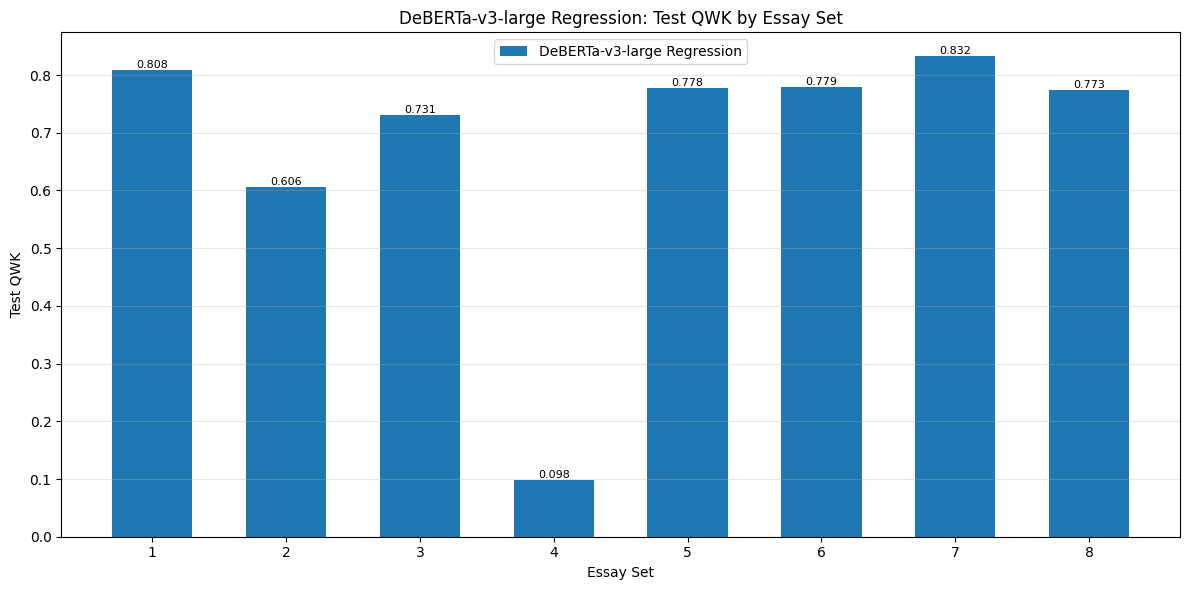

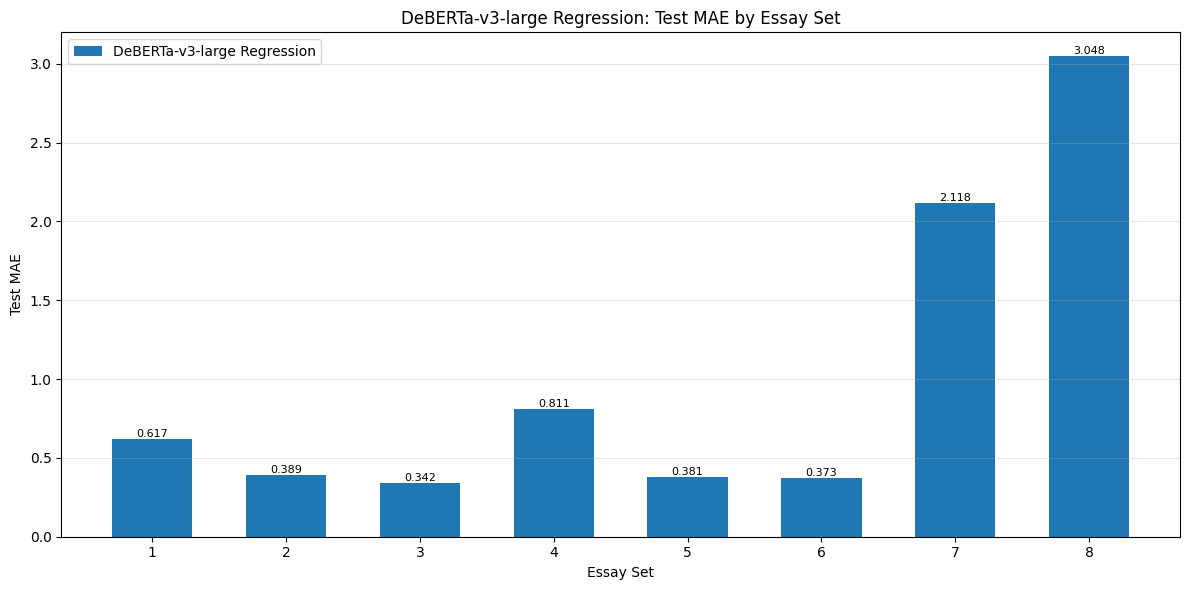

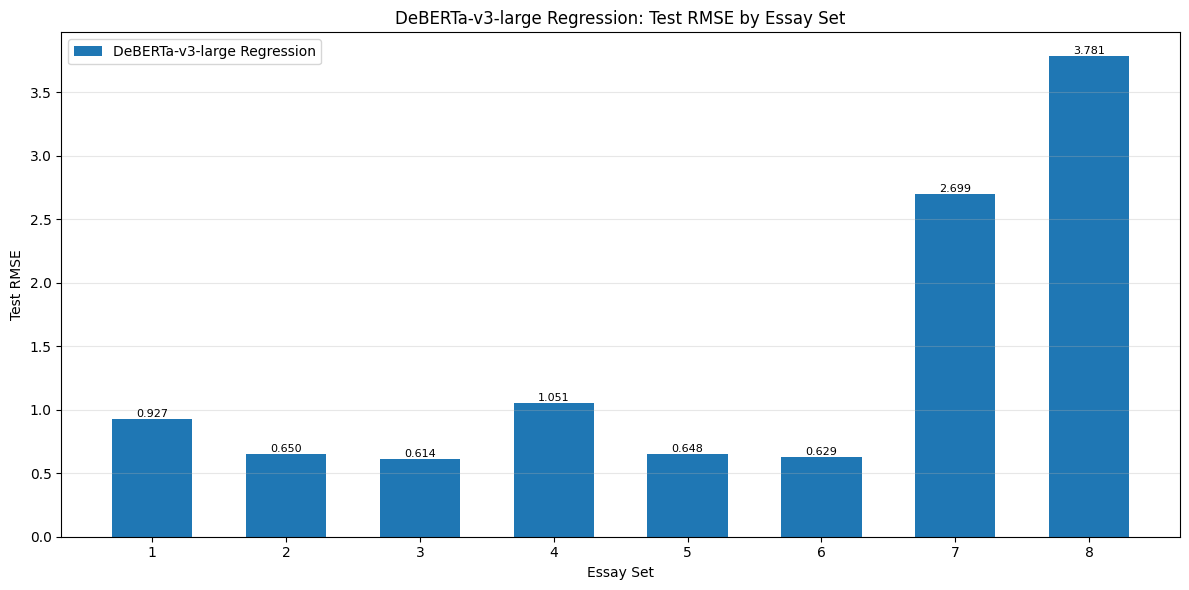


Average summary using optimized thresholds:


,Method,Avg Test QWK,Avg Test MAE,Avg Test RMSE
8,DeBERTa-v3-large Regression,0.6757,1.0098,1.3748


In [13]:
# ============================================================
# Plot DeBERTa results
# ============================================================

plot_df = final_results_df[
    final_results_df["essay_set"].astype(str) != "average"
].copy()

avg_df = final_results_df[
    final_results_df["essay_set"].astype(str) == "average"
].copy()

plot_df["essay_set"] = plot_df["essay_set"].astype(int)


def plot_single_method_metric_by_essay_set(df, metric_col, ylabel, title):
    essay_sets = sorted(df["essay_set"].unique())
    method_name = df["method"].iloc[0]

    values = df.sort_values("essay_set")[metric_col].values

    x = np.arange(len(essay_sets))

    plt.figure(figsize=(12, 6))

    bars = plt.bar(
        x,
        values,
        width=0.6,
        label=method_name,
    )

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.xticks(x, essay_sets)
    plt.xlabel("Essay Set")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


# Optimized threshold plots
plot_single_method_metric_by_essay_set(
    df=plot_df,
    metric_col="test_qwk",
    ylabel="Test QWK",
    title="DeBERTa-v3-large Regression: Test QWK by Essay Set",
)

plot_single_method_metric_by_essay_set(
    df=plot_df,
    metric_col="test_mae",
    ylabel="Test MAE",
    title="DeBERTa-v3-large Regression: Test MAE by Essay Set",
)

plot_single_method_metric_by_essay_set(
    df=plot_df,
    metric_col="test_rmse",
    ylabel="Test RMSE",
    title="DeBERTa-v3-large Regression: Test RMSE by Essay Set",
)

avg_summary = avg_df[["method", "test_qwk", "test_mae", "test_rmse"]].copy()

avg_summary = avg_summary.rename(columns={
    "method": "Method",
    "test_qwk": "Avg Test QWK",
    "test_mae": "Avg Test MAE",
    "test_rmse": "Avg Test RMSE",
})

avg_summary["Avg Test QWK"] = avg_summary["Avg Test QWK"].astype(float).round(4)
avg_summary["Avg Test MAE"] = avg_summary["Avg Test MAE"].astype(float).round(4)
avg_summary["Avg Test RMSE"] = avg_summary["Avg Test RMSE"].astype(float).round(4)

print("\nAverage summary using optimized thresholds:")
display(avg_summary)

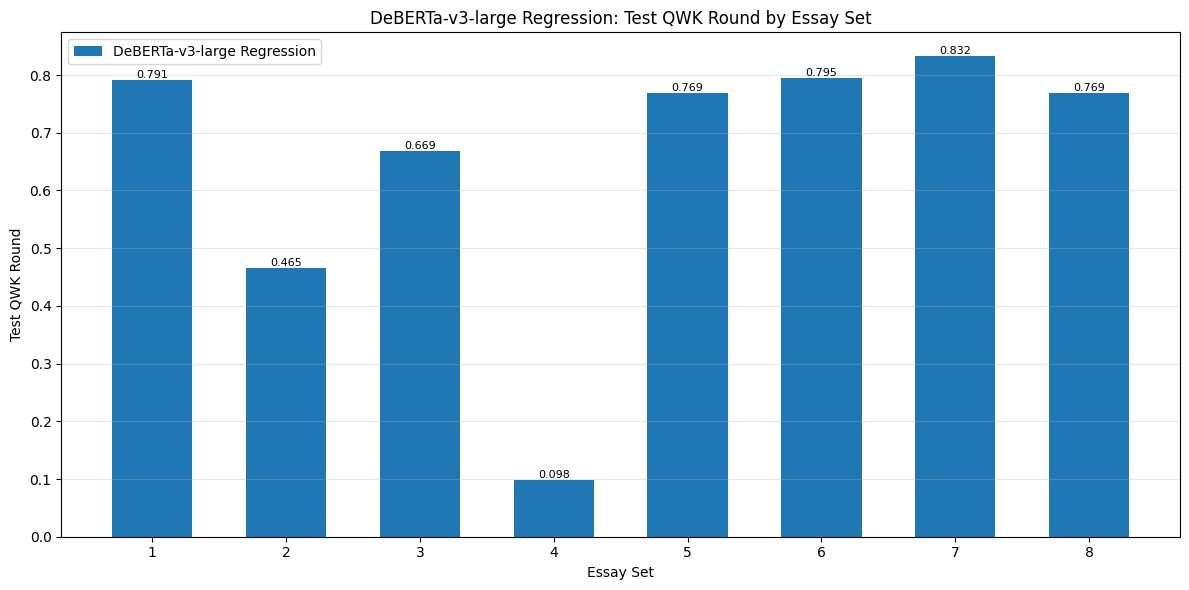

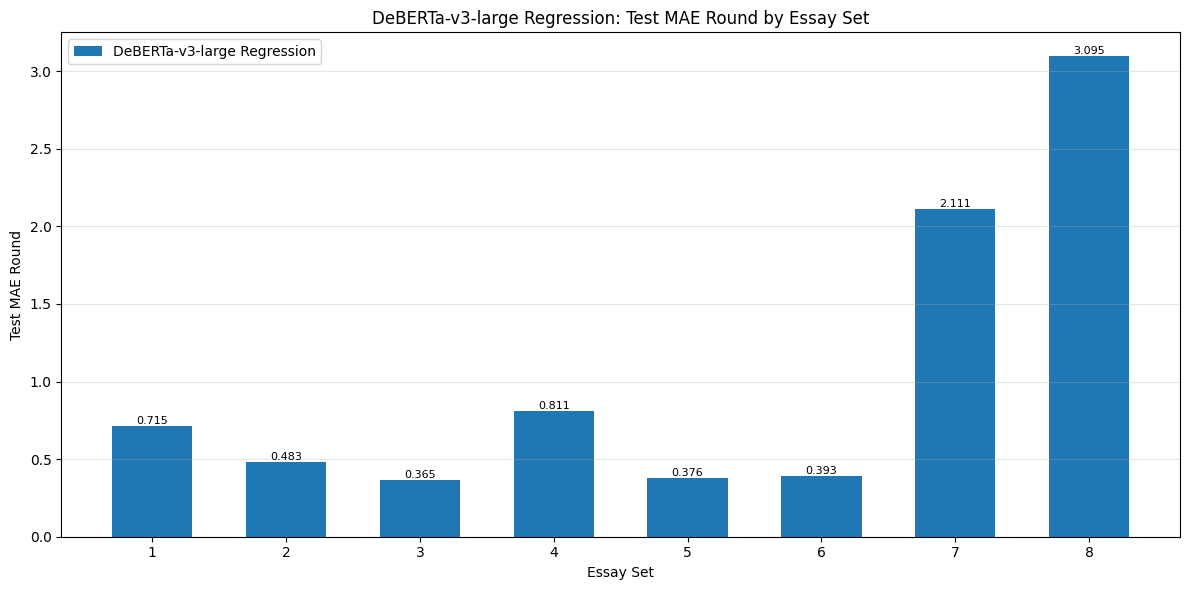

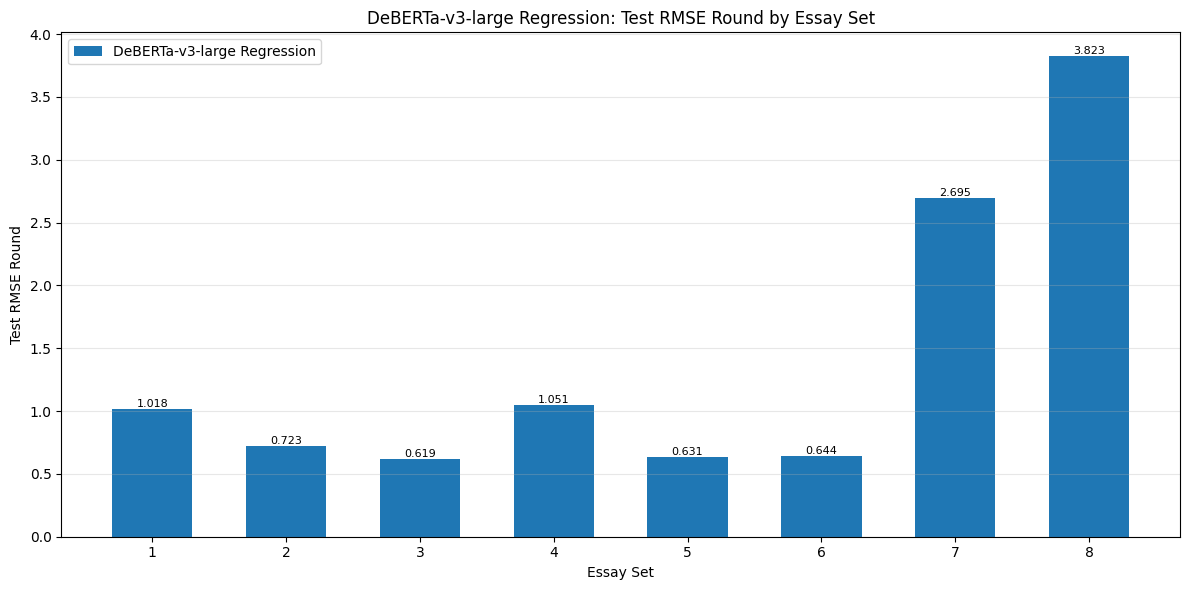


Average summary using normal round:


,Method,Avg Test QWK Round,Avg Test MAE Round,Avg Test RMSE Round
8,DeBERTa-v3-large Regression,0.6486,1.0437,1.4005


In [14]:
# ============================================================
# Plot DeBERTa results using normal round
# ============================================================

plot_single_method_metric_by_essay_set(
    df=plot_df,
    metric_col="test_qwk_round",
    ylabel="Test QWK Round",
    title="DeBERTa-v3-large Regression: Test QWK Round by Essay Set",
)

plot_single_method_metric_by_essay_set(
    df=plot_df,
    metric_col="test_mae_round",
    ylabel="Test MAE Round",
    title="DeBERTa-v3-large Regression: Test MAE Round by Essay Set",
)

plot_single_method_metric_by_essay_set(
    df=plot_df,
    metric_col="test_rmse_round",
    ylabel="Test RMSE Round",
    title="DeBERTa-v3-large Regression: Test RMSE Round by Essay Set",
)

avg_summary_round = avg_df[
    ["method", "test_qwk_round", "test_mae_round", "test_rmse_round"]
].copy()

avg_summary_round = avg_summary_round.rename(columns={
    "method": "Method",
    "test_qwk_round": "Avg Test QWK Round",
    "test_mae_round": "Avg Test MAE Round",
    "test_rmse_round": "Avg Test RMSE Round",
})

avg_summary_round["Avg Test QWK Round"] = avg_summary_round["Avg Test QWK Round"].astype(float).round(4)
avg_summary_round["Avg Test MAE Round"] = avg_summary_round["Avg Test MAE Round"].astype(float).round(4)
avg_summary_round["Avg Test RMSE Round"] = avg_summary_round["Avg Test RMSE Round"].astype(float).round(4)

print("\nAverage summary using normal round:")
display(avg_summary_round)